### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue


### TODOs (Suryansh)
2. Stop word analysis for GT and generated

In [3]:
import pandas as pd
import os
from tqdm.auto import tqdm
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer
from jiwer import wer
import jiwer

# Define a robust transformation pipeline
# This applies data cleaning steps in order, from top to bottom
JIWER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(),                # Convert all text to lowercase
    jiwer.RemovePunctuation(),          # Strip characters like commas, periods, question marks
    jiwer.RemoveMultipleSpaces(),       # Turn multi-spaces into a single space
    jiwer.Strip(),                      # Clean up leading/trailing whitespaces
    jiwer.ReduceToListOfListOfWords()   # Format text tokens perfectly for jiwer's internal engine
])


pd.set_option('display.max_colwidth', None)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    # use_stemmer=True,
    use_stemmer=False
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

def load_df_from_path(AMI_PATH):
    meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", "beam_results_2.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
            continue
    
        # Process lines
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
            line["meeting_name"] = meeting_path.split("/")[-1]

            data.append(line)
            
    # df = pd.DataFrame(lines)
    df = pd.DataFrame(data)
    return df
    
AMI_TRAIN_PATH = '/group/jrwhitehill/llm_asr_clarification/shared/datasets/amicorpus/train'
AMI_VAL_PATH = '/group/jrwhitehill/llm_asr_clarification/shared/datasets/amicorpus/validation'

df = load_df_from_path(AMI_TRAIN_PATH)
df_val = load_df_from_path(AMI_VAL_PATH)

  0%|          | 0/136 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

In [4]:
def check_len(name="beam_results"):
    meeting_paths = [entry.path for entry in os.scandir("/group/jrwhitehill/llm_asr_clarification/shared/datasets/amicorpus/train")]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", f"{name}.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
            continue
    
        # Process lines
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
            line["meeting_name"] = meeting_path.split("/")[-1]
    
            data.append(line)
            
    # df = pd.DataFrame(lines)
    beam = pd.DataFrame(data)
    print(len(beam))

check_len("beam_results")
check_len("beam_results_2")

  0%|          | 0/136 [00:00<?, ?it/s]

88717


  0%|          | 0/136 [00:00<?, ?it/s]

87358


In [5]:
print(df.shape)
print(df_val.shape)

(87358, 17)
(10419, 17)


In [3]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,beam_4_text,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob,meeting_name
0,Okay.,Okay,-0.666108,-9.1875,Okay.,-0.165992,-6.96875,Okay,-0.666108,-9.18750,Okay.,-0.165992,-6.96875,Okay?,-0.832697,-9.31250,ES2005d
1,"Okay, almost there.",Okay I was there,-0.789106,-6.1250,OK? I'm listening.,-1.217811,-5.09375,Okay.,-0.231215,-7.00000,I was there.,-0.545655,-5.46875,Okay.,-0.231215,-7.00000,ES2005d
2,Okay.,Okay,-0.634828,-9.1875,OK.,-0.716196,-7.31250,Okay.,-0.134573,-6.96875,Okay...,-2.051196,-7.28125,Okay.,-0.134573,-6.96875,ES2005d


In [6]:
import re
import string

def normalize_text(text: str) -> str:
    """Mirrors the jiwer text normalization pipeline, except for last stage"""
    if not text:
        return ""
    
    # 1. jiwer.ToLowerCase()
    text = text.lower()
    
    # 2. jiwer.RemovePunctuation()
    # Removes standard punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. jiwer.RemoveMultipleSpaces()
    text = re.sub(r'\s+', ' ', text)
    
    # 4. jiwer.Strip()
    text = text.strip()
    
    return text

In [7]:
def process_columns(df):
    llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
    asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]
    
    llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
    asr_logprobs = torch.tensor(df[asr_logprob_columns].values)
    
    # # ALL BEAMS
    # scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
    # highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
    # highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)

    # JUST BEAM 1
    scores = llm_logprobs
    highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]


    # AGGREGATED STATS
    df['max_llmlogprobs'] = torch.max(llm_logprobs, dim=1).values.numpy()
    df['min_llmlogprobs'] = torch.min(llm_logprobs, dim=1).values.numpy()
    df['spread_llmlogprobs'] = df['max_llmlogprobs'] - df['min_llmlogprobs']

    df['max_asrlogprobs'] = torch.max(asr_logprobs, dim=1).values.numpy()
    df['min_asrlogprobs'] = torch.min(asr_logprobs, dim=1).values.numpy()
    df['spread_asrlogprobs'] = df['max_asrlogprobs'] - df['min_asrlogprobs']

    df['highest_score'] = highest_scores.numpy()
    
    df['text'] = df['beam_1_text']
    df['num_tokens_text'] = df['beam_1_text'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    df['num_tokens_gt'] = df['gt'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    
    
    df["rougeL"] = [
        rouge_l(normalize_text(pred), normalize_text(ref)).fmeasure
        for pred, ref in zip(df["text"], df["gt"])
    ]
    df["wer"] = [
        min(1.0, wer(reference = ref, hypothesis = pred, reference_transform = JIWER_TRANSFORM, hypothesis_transform = JIWER_TRANSFORM))
        for pred, ref in zip(df["text"], df["gt"])
    ]

process_columns(df)
process_columns(df_val)

In [9]:
df.to_json('/group/jrwhitehill/llm_asr_clarification/shared/datasets/mistranscription_detector_datasets/train.json', orient='records',indent=4)
df_val.to_json('/group/jrwhitehill/llm_asr_clarification/shared/datasets/mistranscription_detector_datasets/val.json', orient='records',indent=4)

In [10]:
df.head(5)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,...,spread_llmlogprobs,max_asrlogprobs,min_asrlogprobs,spread_asrlogprobs,highest_score,text,num_tokens_text,num_tokens_gt,rougeL,wer
0,Okay.,Okay,-0.666108,-9.1875,Okay.,-0.165992,-6.96875,Okay,-0.666108,-9.18750,...,2.34375,-0.165992,-0.832697,0.666705,-9.1875,Okay,2,3,1.000000,0.000000
1,"Okay, almost there.",Okay I was there,-0.789106,-6.1250,OK? I'm listening.,-1.217811,-5.09375,Okay.,-0.231215,-7.00000,...,1.90625,-0.231215,-1.217811,0.986596,-6.1250,Okay I was there,5,6,0.571429,0.666667
2,Okay.,Okay,-0.634828,-9.1875,OK.,-0.716196,-7.31250,Okay.,-0.134573,-6.96875,...,2.21875,-0.134573,-2.051196,1.916623,-9.1875,Okay,2,3,1.000000,0.000000
3,"We'll sta I'll use the PowerPoint, I guess.","Well, I'll use the PowerPoint I guess.",-0.198878,-5.1250,"will still use the powerpoint, I guess.",-0.719161,-5.43750,"I'll use the PowerPoint, I guess.",-0.221139,-5.37500,...,0.50000,-0.198878,-0.719161,0.520283,-5.1250,"Well, I'll use the PowerPoint I guess.",11,13,0.933333,0.125000
4,"How was that, was that fun?","How was that, was that?",-0.126335,-5.1875,"How was that, was that?",-0.126335,-5.18750,"How was that, was that?",-0.126335,-5.18750,...,0.84375,-0.126335,-0.753671,0.627336,-5.1875,"How was that, was that?",8,9,0.909091,0.166667


# whisper text len vs. ground truth text len

In [11]:
import matplotlib.pyplot as plt

def corr_analysis(df, x='highest_score', y='rougeL'):
    df.plot.scatter(x=x, y=y)
    
    # Display the plot
    plt.show()
    
    from scipy.stats import pearsonr
    
    result = pearsonr(df[x], df[y])
    
    print(f"Pearson r: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")

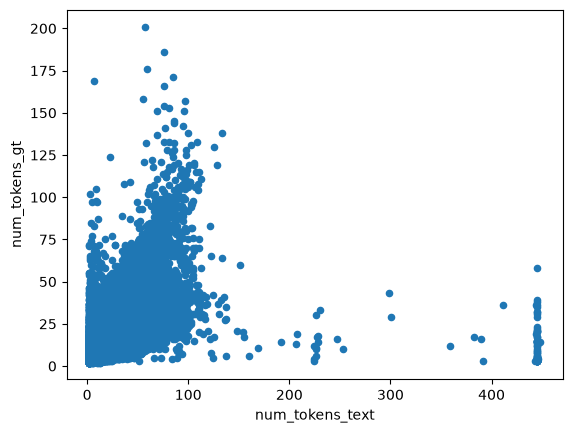

Pearson r: 0.6158
P-value: 0.0000


In [12]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

In [13]:
# Filter out seqs with tokens greater than or equal to 400 in the generated text
df = df[df['num_tokens_text'] < 400]
df_val = df_val[df_val['num_tokens_text'] < 400]

short_idx = df['num_tokens_text'] <= 5

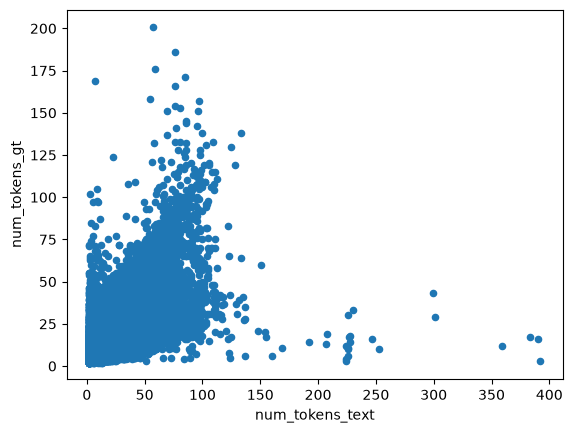

Pearson r: 0.7994
P-value: 0.0000


In [14]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

<Axes: >

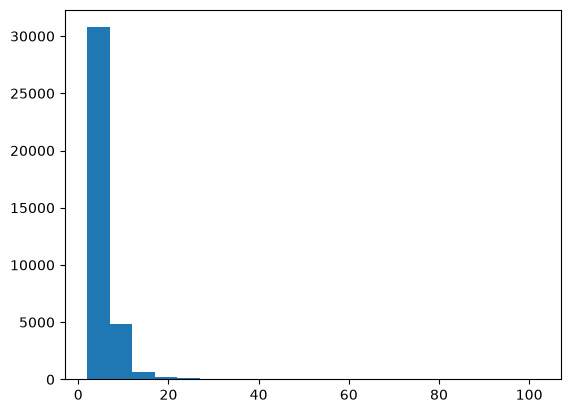

In [15]:
df[short_idx]['num_tokens_gt'].hist(bins=20, grid=False)

In [16]:
# Number of short sequences
sum(short_idx)

36658

In [17]:
# Get the number of times GT sequences were longer than generated
sum((df['num_tokens_gt'] > df['num_tokens_text']))

54457

In [18]:
# Num of times GT sequences are longer than generated short seqs
sum((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))

28121

In [19]:
# % of GT seqs longer than generated short seqs 
len(df[((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))])/len(df[short_idx])

0.7671176823612854

In [20]:
# % of when long seqs had short transcriptions (mostly mistranscriptions)
len(df[((df['num_tokens_gt'] > 5) & (short_idx))])/len(df[short_idx])

0.2907141688035354

In [21]:
# Sample 10 generated short seqs and their equivalent GT
df[short_idx][['text','gt']].sample(10)

,text,gt
37287,Yeah.,Yeah.
73851,you,Oh.
84113,Yeah.,And then the so the yeah.
22619,Great training,"Great, great."
72842,for.,Really?
55374,you,Yeah.
85766,It's,"forty, forty one is but see, he has already."
61086,problem.,Mm-hmm.
35417,to be used.,Yeah.
40519,no,Or do y do you find it helpful to have it?


# errors analysis

In [22]:
df['wer'].describe()

count    87295.000000
mean         0.711589
std          0.343015
min          0.000000
25%          0.400000
50%          1.000000
75%          1.000000
max          1.000000
Name: wer, dtype: float64

In [23]:
df[['text','gt','wer','rougeL']].sample(5)

,text,gt,wer,rougeL
2760,Where can components work?,Uh working components.,1.000000,0.285714
28071,The other one was audio,The other one was audio settings.,0.166667,0.909091
829,Okay.,Okay.,0.000000,1.000000
39207,"then yes, then I would it doesn't what else wouldn't need to be technologically","Then yes, then I would well it isn't what else would it need for it to be technologically innovative?",0.368421,0.727273
4408,you,Mm-hmm.,1.000000,0.000000


In [24]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on ROUGE L
sum(df['rougeL'] < 0.5)/len(df)

0.5872043072340913

In [25]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on WER
sum(df['wer'] > 0.5)/len(df)

0.6698894552952632

In [26]:
# Recaluculate short indices
short_idx = df['num_tokens_text'] <= 5

In [27]:
# Get indices of mistranscribed seqs based on ROUGE L and WER
errors_rougeL_idx = df['rougeL'] < 0.5
errors_wer_idx = df['wer'] > 0.5

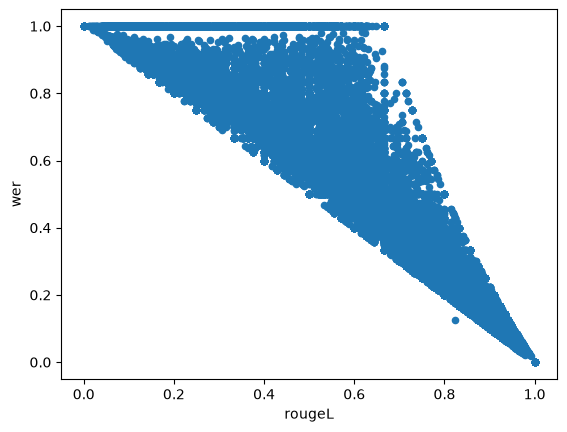

Pearson r: -0.9480
P-value: 0.0000


In [28]:
corr_analysis(df,'rougeL','wer')

<Axes: >

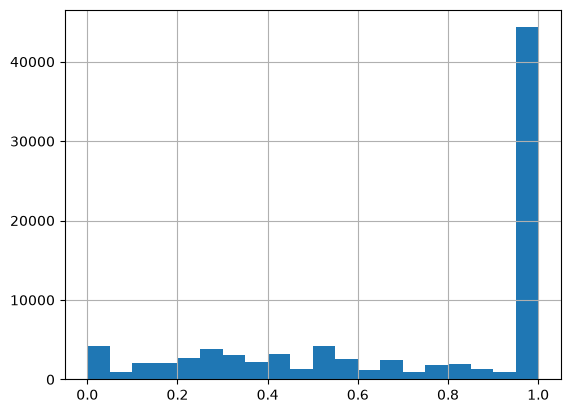

In [29]:
# Generate hist distr of WER
df['wer'].hist(bins=20)

In [56]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
9042,You,Okay.,0.000000,1.000000
83570,it's,It's it's it's parent child relationship.,0.285714,0.833333
5315,Part 1.,Participant two.,0.000000,1.000000
76229,"look and feel. So just walk through it step by step. I mean, it's at fancy. Everything. I believe. I believe it's fancy. Yeah, but apparently we shouldn't evaluate yet. Yeah.","So Uh well appar Yeah, but apparently uh we shouldn't evaluate yet.",0.372093,1.000000
35885,I love that part of my film. I'm waiting for the get-come to you so you don't get,"Well, you know, apa pa apart from apart all apart from waiting for the get get Camtasia sorted out.",0.216216,0.947368
7898,I'm,Um.,0.000000,1.000000
64343,you,Okay.,0.000000,1.000000
23149,"I'll be right, we did.","Right, we did.",0.750000,0.666667
23163,"No, just with a...",This is what they uh what they mean.,0.000000,1.000000
28120,Spuck. Yeah.,Yeah.,0.666667,1.000000


In [58]:
# Look at mistranscriptions according to ROUGE-L
df[df['rougeL'] < 0.5][['meeting_name', 'text','gt','rougeL', 'wer']].sample(10)

,meeting_name,text,gt,rougeL,wer
54319,ES2006d,We are meeting defeat on sea or we say we are going to stick your legates on the ground.,Are are we admitting defeat on C_ or are we saying we're gonna stick a locator on the T_V_?,0.421053,0.631579
23941,IS1000b,you,Mm.,0.000000,1.000000
50418,TS3009a,"you have to, it's a video on it.",You have to use one hand.,0.428571,0.833333
7020,TS3009d,you,Yeah.,0.000000,1.000000
72519,IS1005a,"So, volume can","Ah, n.",0.000000,1.000000
54334,ES2006d,See you later.,It's locatable?,0.000000,1.000000
3018,IS1003d,"the ball has no idea. It's very convenient for you to tend the ball to change the channel. And where is the voice recognition? It's embedded. Yeah, that's the second point. First one is we have to judge the",I have no idea what If it is fancy or not.,0.120000,1.000000
72627,ES2016d,That's in put that just rapidly and for we had,That just represents the infrared uh beam.,0.235294,1.000000
55539,IS1002c,to watch and watch the later,Trend watching I guess.,0.000000,1.000000
4930,EN2004a,"I mean, if it's in carrots.",Um okay.,0.000000,1.000000


In [54]:
# Look at normal transcriptions according to ROUGE-L
df[df['rougeL'] >= 0.5][['meeting_name', 'text','gt','rougeL', 'wer']].sample(10)

,meeting_name,text,gt,rougeL,wer
15947,ES2014d,the more important of the options.,But which do you think or which do we think is the more important of the options?,0.521739,0.647059
36730,EN2009c,represents everything in the NXT thing is.,And then the N_X_T_ thing is just a splitter.,0.500000,0.666667
76827,ES2014c,"If you think they're the old tortures which you wind up, I can't idea.",Any of you think of kind of like the the old torches which you wind up um.,0.516129,0.647059
56165,ES2003c,People like Spongebii too.,People like spongy material.,0.500000,0.500000
68986,IN1001,"Okay, so you have applied the shot detector to some of the synities video, this one and so we can basically just comment on this quickly remind what the shot detector is, how the shot detector is working, basically","To so you have applied the shot detector to some of the CINETIS video, or at least one, and uh so we can basically maybe just comment on on this, maybe quickly remind what the shot detector is how the shot detector is working, basically.",0.857143,0.200000
40886,ES2003b,I've looked at a couple of other remote control models just for an idea of basic design principles.,I've looked at looked at a num uh couple of other uh remote control models just for an idea of basic design principles.,0.878049,0.217391
19528,ES2016b,"What we're going to use, let's go with our rounded kind of fit in your hand. Let's explore the possibility of having the two P.",Let's go with our our uh rounded kind of fit in your hand let's explore uh the the uh possibility of having the two-piece.,0.734694,0.500000
85888,IS1000c,different designs. yeah a round of a set of three four different,"Yeah a range of uh yeah, a set of three, four different aspects.",0.720000,0.461538
29217,ES2013d,Oh yes.,Yes.,0.666667,1.000000
73314,TS3008d,Okay for now this is okay,"Okay, for now this is this is okay.",0.857143,0.250000


In [69]:
percent_mistranscribed = len(df[df['rougeL'] < 0.5]) / len(df)
percent_mistranscribed_val = len(df_val[df_val['rougeL'] < 0.5]) / len(df_val)
print(f"% Mistranscribed sentences in Train Set: {percent_mistranscribed}")
print(f"% Mistranscribed sentences in Val Set: {percent_mistranscribed_val}")

% Mistranscribed sentences in Train Set: 0.5872043072340913
% Mistranscribed sentences in Val Set: 0.5791142280718609


In [29]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt']].sample(10)

,text,gt
7878,you,Yes.
80679,"Yeah,","Yeah, black I think is is the standard."
81615,is available.,Yeah.
20365,Okay.,Mm.
51447,Okay?,Yeah.
63809,My,Well five also uh Norman please.
83609,"So you can't click them. Oh yeah, you said.",So you can't collect them.
36558,"I mean, that's just the way you want it. Hopefully, that's the highest, that's why. Of course, a lot of things that can do that fits the language part.","It ho hopefu uh hopefully that's yeah, I guess it's that's why I dre As well."
10681,you,"No, one."
70084,yeah yeah,information.


In [30]:
print(df['rougeL'].describe())
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

count    87295.000000
mean         0.363307
std          0.362886
min          0.000000
25%          0.000000
50%          0.297297
75%          0.705882
max          1.000000
Name: rougeL, dtype: float64
50th quartile for rougeL is: 0.30
25th quartile for rougeL is: 0.00


In [31]:
errors_idx = errors_rougeL_idx

In [32]:
p_error = len(df[errors_idx])/len(df)
print(f"P(error) = {p_error:.3f}")
p_short = len(df[short_idx])/len(df)
print(f"P(short) = {p_short:.3f}")

p_error_given_short = len(df[(short_idx) & (errors_idx)]) / len(df[short_idx])
print(f"P(error|short) = {p_error_given_short:.3f}")

p_error_given_long = len(df[(~short_idx) & (errors_idx)]) / len(df[~short_idx])
print(f"P(error|long) = {p_error_given_long:.3f}")

p_short_given_error = len(df[(short_idx) & (errors_idx)]) / len(df[errors_idx])
print(f"P(short|error) = {p_short_given_error:.3f}")
print(f"P(long|error) = {1-p_short_given_error:.3f}")

P(error) = 0.587
P(short) = 0.420
P(error|short) = 0.847
P(error|long) = 0.399
P(short|error) = 0.605
P(long|error) = 0.395


In [33]:
from statsmodels.stats.proportion import proportions_ztest

# Number of errors in each group
n_errors_short = ((short_idx) & (errors_idx)).sum()
n_errors_long = ((~short_idx) & (errors_idx)).sum()

# Number of samples in each group
n_short = short_idx.sum()
n_long = (~short_idx).sum()

# Two-proportion z-test
count = [n_errors_short, n_errors_long]
nobs = [n_short, n_long]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Short error rate: {n_errors_short/n_short:.3f}")
print(f"Long error rate:  {n_errors_long/n_long:.3f}")
print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.6f}")

Short error rate: 0.847
Long error rate:  0.399
z = 132.425
p = 0.000000


# filtering for actual long utterances

<Axes: >

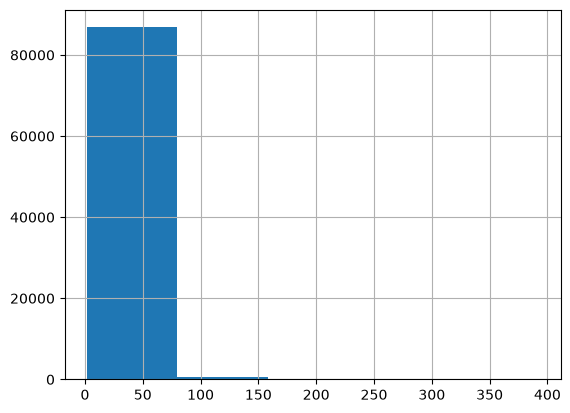

In [34]:
df['num_tokens_text'].hist(bins=5)

In [35]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'
longs_df = df[~short_idx]
shorts_df = df[short_idx]

In [36]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

# def standardize_df(datfram):
#     datfram['normalized_score'] = (
#         datfram['highest_score'] - datfram['highest_score'].mean()
#     )/datfram['highest_score'].std()

# standardize_df(df)
# standardize_df(shorts_df)
# standardize_df(longs_df)

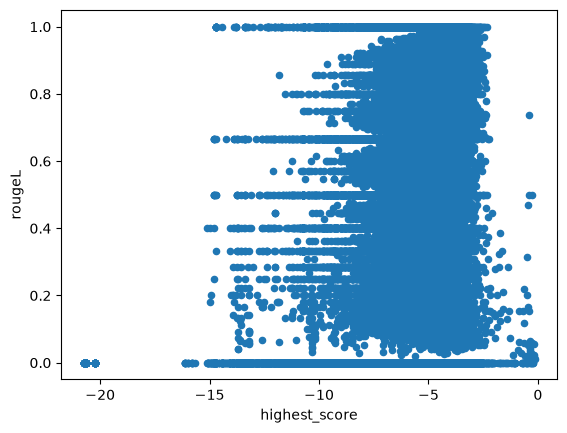

Pearson r: 0.5263
P-value: 0.0000


In [37]:
corr_analysis(df)

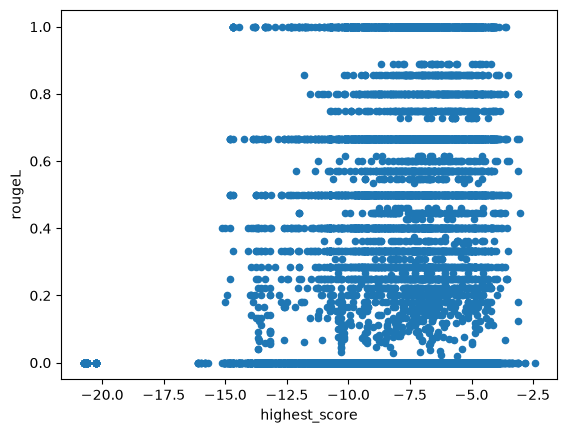

Pearson r: 0.3251
P-value: 0.0000


In [38]:
corr_analysis(shorts_df)

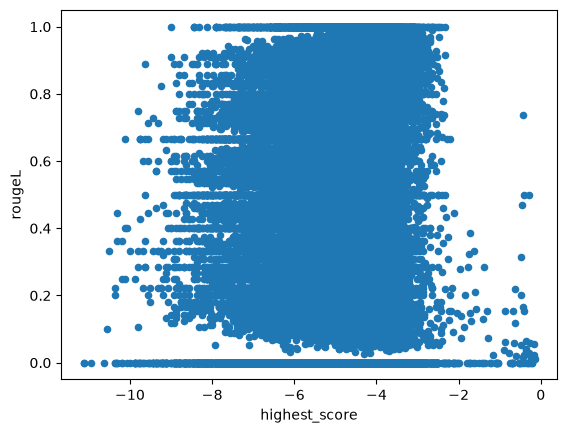

Pearson r: 0.1807
P-value: 0.0000


In [39]:
corr_analysis(longs_df)

<Axes: >

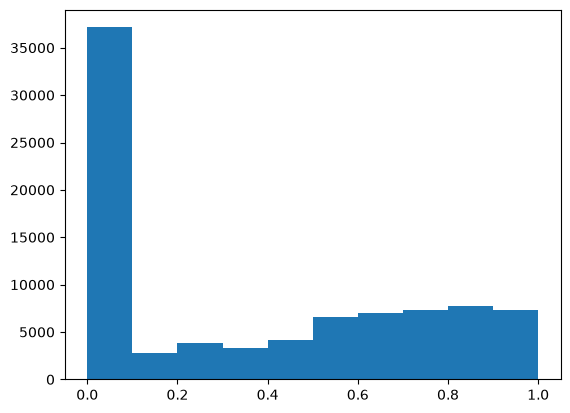

In [40]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

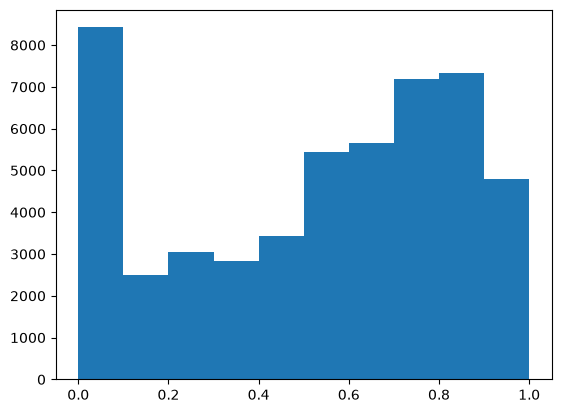

In [41]:
longs_df['rougeL'].hist(grid=False, bins=10)

<Axes: >

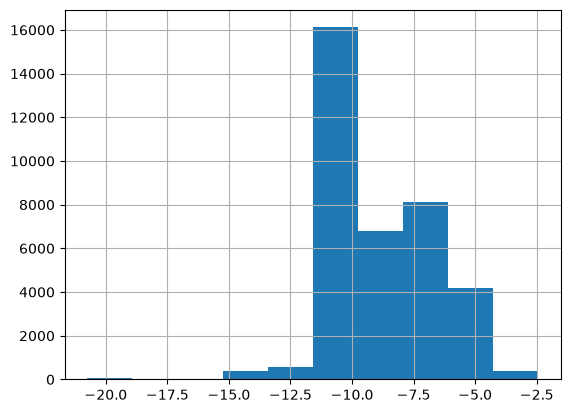

In [42]:
shorts_df['highest_score'].hist()

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["highest_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["highest_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, -df["highest_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["highest_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [44]:
pd.set_option('display.max_colwidth', None)

Best threshold: -4.8030
ROCAUC: 0.7575447963437375
Best F1: 0.7458
Precision at best F1: 0.6691
Recall at best F1: 0.8424



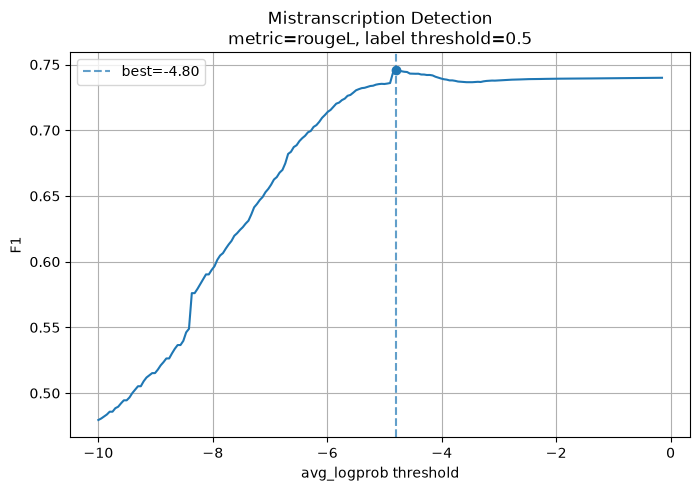

In [45]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -0.1504
ROCAUC: 0.5794649496709552
Best F1: 0.5708
Precision at best F1: 0.3994
Recall at best F1: 1.0000



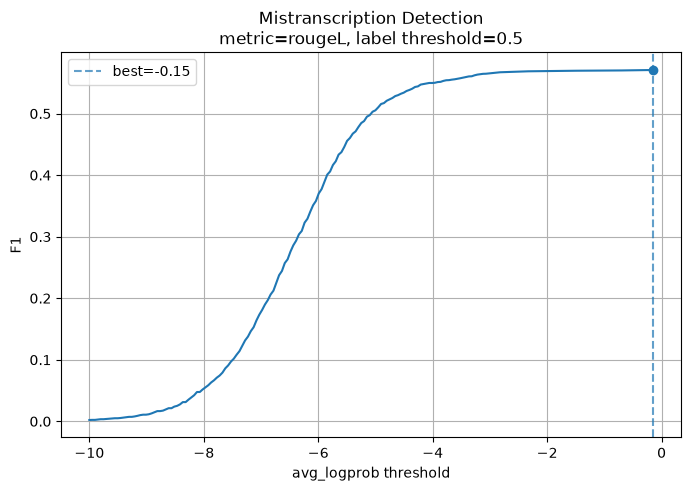

In [46]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -5.9414
ROCAUC: 0.7802645631169068
Best F1: 0.7131
Precision at best F1: 0.7142
Recall at best F1: 0.7121



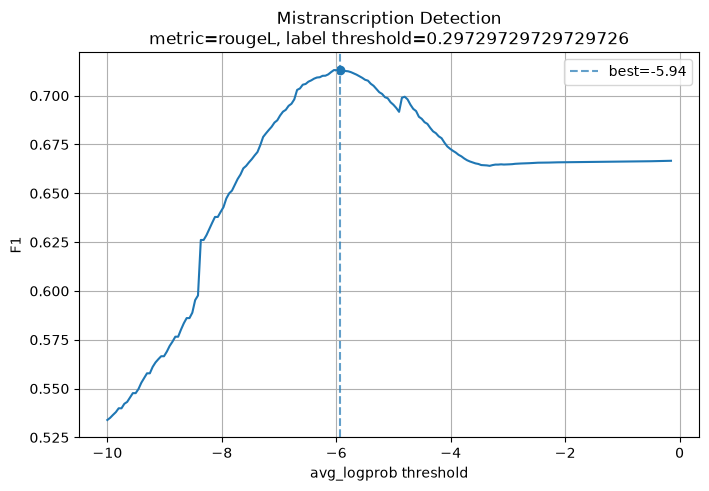

In [47]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: -0.1504
ROCAUC: 0.5554304457637116
Best F1: 0.4296
Precision at best F1: 0.2736
Recall at best F1: 0.9999



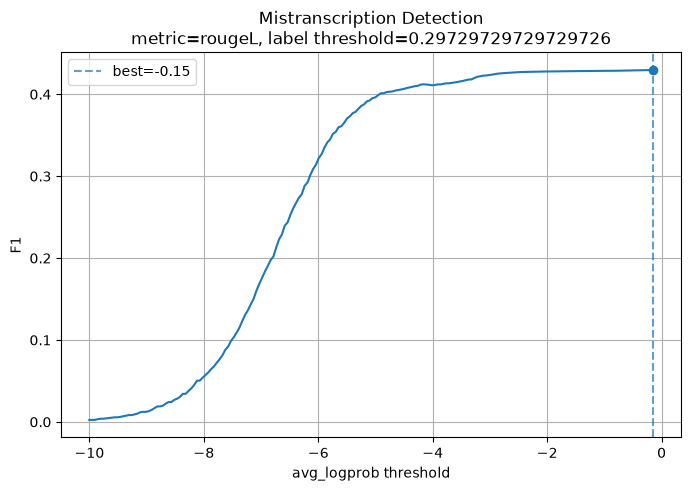

In [48]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# ml stuff

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df['y_true'] = errors_idx
df_val['y_true'] = df_val['rougeL'] < 0.5

FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
]

def train_and_eval_rf(FEATURES):
    TARGET = "y_true"
    
    # --------------------
    # Train RF
    # --------------------
    
    X_train = df[FEATURES]
    y_train = df[TARGET].astype(int)
    
    X_val = df_val[FEATURES]
    y_val = df_val[TARGET].astype(int)
    
    rf = RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1,
    )
    
    rf.fit(X_train, y_train)
    
    # --------------------
    # Predictions
    # --------------------
    
    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs = rf.predict_proba(X_val)[:, 1]
    
    # --------------------
    # Overall AUROC
    # --------------------
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"Train AUROC: {train_auc:.4f}")
    print(f"Val   AUROC: {val_auc:.4f}")
    
    # --------------------
    # Short / Long subsets
    # --------------------
    
    train_shorts_idx = df["num_tokens_text"] <= 5
    val_shorts_idx = df_val["num_tokens_text"] <= 5
    
    def subset_auc(y, probs, mask):
        if y[mask].nunique() < 2:
            return float("nan")
        return roc_auc_score(y[mask], probs[mask])
    
    print("\nTRAIN")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_train, train_probs, train_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_train, train_probs, ~train_shorts_idx):.4f}"
    )
    
    print("\nVALIDATION")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_val, val_probs, val_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_val, val_probs, ~val_shorts_idx):.4f}"
    )


    def elbow_plot(
        y_true,
        scores,
        threshold_range=None,
        n_thresholds=200,
    ):
        """
        Finds the threshold maximizing F1.
    
        Parameters
        ----------
        y_true : array-like of bool/int
            Ground truth labels (1 = error).
    
        scores : array-like
            Probability or score where LARGER means MORE likely to be an error.
    
        threshold_range : (min, max) or None
            Threshold search range. Defaults to score min/max.
    
        Returns
        -------
        best_threshold, best_f1, best_precision, best_recall
        """
    
        y_true = np.asarray(y_true).astype(int)
        scores = np.asarray(scores)
    
        if threshold_range is None:
            tmin = scores.min()
            tmax = scores.max()
        else:
            tmin, tmax = threshold_range
    
        thresholds = np.linspace(tmin, tmax, n_thresholds)
    
        f1s = []
        precisions = []
        recalls = []
    
        for t in thresholds:
            pred = scores >= t
    
            precisions.append(
                precision_score(y_true, pred, zero_division=0)
            )
            recalls.append(
                recall_score(y_true, pred, zero_division=0)
            )
            f1s.append(
                f1_score(y_true, pred, zero_division=0)
            )
    
        f1s = np.array(f1s)
        precisions = np.array(precisions)
        recalls = np.array(recalls)
    
        best_idx = np.argmax(f1s)
    
        best_threshold = thresholds[best_idx]
        best_f1 = f1s[best_idx]
        best_precision = precisions[best_idx]
        best_recall = recalls[best_idx]
    
        plt.figure(figsize=(7,4))
        plt.plot(thresholds, f1s, label="F1")
        plt.plot(thresholds, precisions, label="Precision")
        plt.plot(thresholds, recalls, label="Recall")
    
        plt.axvline(
            best_threshold,
            linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}",
        )
    
        plt.xlabel("Threshold")
        plt.ylabel("Metric")
        plt.title("Threshold selection")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Best F1:        {best_f1:.4f}")
        print(f"Precision:      {best_precision:.4f}")
        print(f"Recall:         {best_recall:.4f}")

    val_probs = rf.predict_proba(X_val)[:, 1]
    elbow_plot(y_val[~val_shorts_idx], val_probs[~val_shorts_idx])

    return rf

Train AUROC: 0.8432
Val   AUROC: 0.8195

TRAIN
Short AUROC: 0.8581
Long  AUROC: 0.7300

VALIDATION
Short AUROC: 0.8361
Long  AUROC: 0.6970


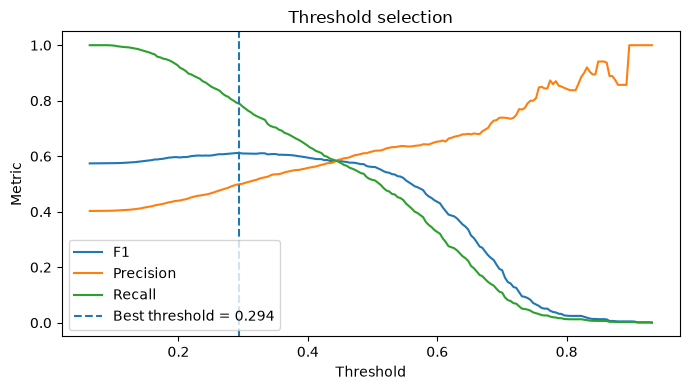

Best threshold: 0.2943
Best F1:        0.6116
Precision:      0.4992
Recall:         0.7891


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [50]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.8944
Val   AUROC: 0.8711

TRAIN
Short AUROC: 0.8876
Long  AUROC: 0.8370

VALIDATION
Short AUROC: 0.8605
Long  AUROC: 0.8059


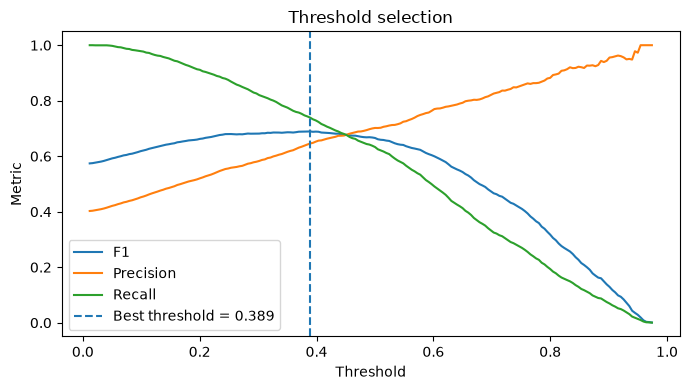

Best threshold: 0.3890
Best F1:        0.6894
Precision:      0.6459
Recall:         0.7391


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [51]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob"
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.9114
Val   AUROC: 0.8813

TRAIN
Short AUROC: 0.9017
Long  AUROC: 0.8684

VALIDATION
Short AUROC: 0.8627
Long  AUROC: 0.8280


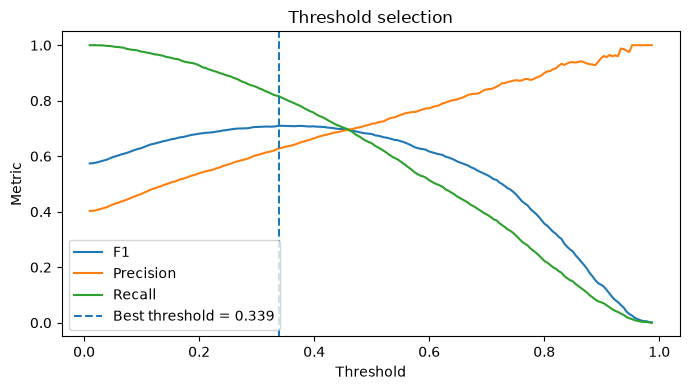

Best threshold: 0.3388
Best F1:        0.7098
Precision:      0.6280
Recall:         0.8161


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [52]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9167
Val   AUROC: 0.8857

TRAIN
Short AUROC: 0.9049
Long  AUROC: 0.8779

VALIDATION
Short AUROC: 0.8651
Long  AUROC: 0.8368


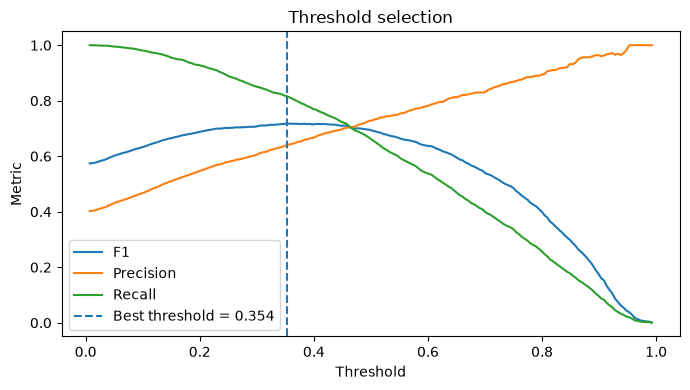

Best threshold: 0.3537
Best F1:        0.7177
Precision:      0.6409
Recall:         0.8153


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tot

In [53]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9158
Val   AUROC: 0.8865

TRAIN
Short AUROC: 0.9052
Long  AUROC: 0.8760

VALIDATION
Short AUROC: 0.8683
Long  AUROC: 0.8370


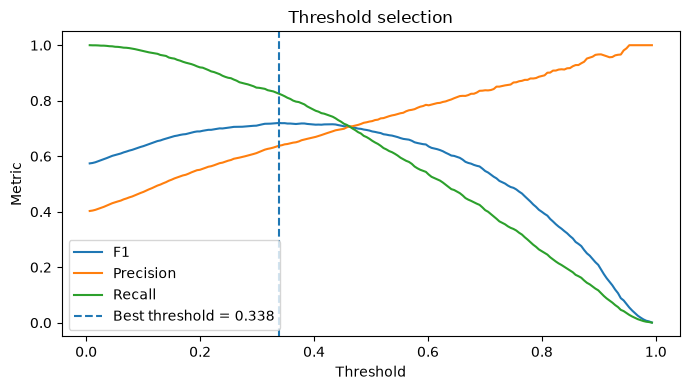

Best threshold: 0.3385
Best F1:        0.7197
Precision:      0.6378
Recall:         0.8258


In [54]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
rf = train_and_eval_rf(FEATURES)

In [55]:
os.getcwd()

'/home/pkongsomjit/Projects/llm_asr_clarification/src/llm_asr_clarification'

In [56]:
import pickle

# 1. Save your trained model
with open('/home/pkongsomjit/Projects/llm_asr_clarification/shared/model_weights/rf_model2.pkl', 'wb') as file:
    pickle.dump(rf, file)
